# Rates of Change in Real Data

**This notebook is self-contained; it recaps finite differences and smoothing before applying them.**

Everything so far had a known answer to check against. Real data doesn't. This notebook takes
**fourteen years of hourly electricity demand** for the Dayton, Ohio region and asks a question no
formula can answer: how fast is demand rising or falling, and when?

The derivative of a demand curve is what a grid operator actually needs, not "how much power is being
used" but "how quickly is that changing," because ramping generation up and down takes time.

## Learning objectives

- Compute a numerical derivative of a real, noisy time series.
- Choose a **resampling** interval appropriate to the question being asked.
- Interpret the sign and size of the derivative in the units of the problem.

## Background

Two tools from the previous notebooks, both needed here:

- The **central difference** $f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$ estimates a rate of change
  from values alone.
- Differentiation **amplifies noise**, so a real series must be **smoothed first**. Averaging to a
  coarser interval (daily means rather than hourly readings) does the same job as a rolling window and
  is natural for time series.

The units matter and carry through the arithmetic. Demand is in megawatts (MW) and time in hours, so
the derivative is in **MW per hour**, how many megawatts the load rises or falls each hour.

## This notebook covers

1. The data: 14 years of hourly demand.
2. Three time scales: a day, a month, a year.
3. The hourly rate of change, and why raw differencing struggles.
4. Smoothing to a daily average, then differentiating.

**Prerequisites:** `U3-4_NumericalDerivatives-2_Noise`

**Dataset:** `DAYTON_hourly.csv`, hourly megawatt load, from the shared dataset library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. The data

Hourly readings of total electricity demand, in megawatts, spanning well over a decade. The row
count and date range are printed below, far too many points to plot raw and read anything from.

In [2]:
power = pd.read_csv(helpers.data('Hourly Energy Consumption/DAYTON_hourly.csv'),
                    parse_dates=['Datetime'], index_col='Datetime')
power = power.sort_index()

print(f"{len(power):,} hourly readings")
print(f"from {power.index.min()}  to  {power.index.max()}")
print(f"demand ranges from {power['DAYTON_MW'].min():,.0f} to {power['DAYTON_MW'].max():,.0f} MW")
power.head()

121,275 hourly readings
from 2004-10-01 01:00:00  to  2018-08-03 00:00:00
demand ranges from 982 to 3,746 MW


,DAYTON_MW
Datetime,
2004-10-01 01:00:00,1621.0
2004-10-01 02:00:00,1536.0
2004-10-01 03:00:00,1500.0
2004-10-01 04:00:00,1434.0
2004-10-01 05:00:00,1489.0


## 2. Three time scales

The same series looks like a completely different signal depending on how far you stand back. Zoomed
into a **day** you see the daily rhythm of waking and sleeping; over a **month**, a weekly pattern;
over a **year**, the seasonal swing of heating and cooling.

Which one you plot determines which derivative question you can answer.

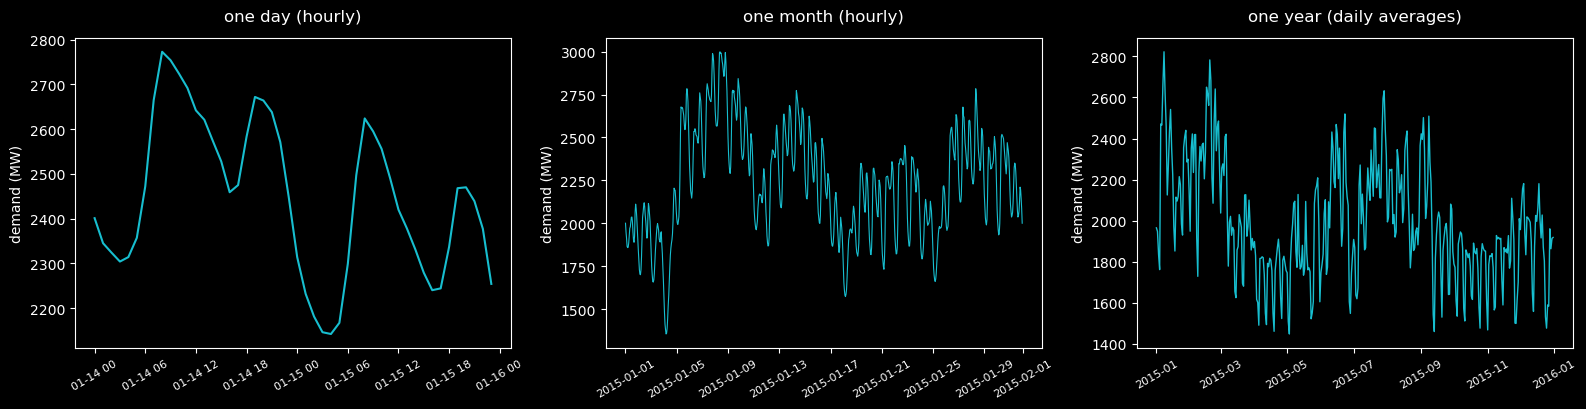

In [3]:
mw = power['DAYTON_MW']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

day = mw['2015-01-14':'2015-01-15']
axes[0].plot(day.index, day.values, color="tab:cyan", lw=1.5)
axes[0].set_title("one day (hourly)", pad=12)

month = mw['2015-01-01':'2015-01-31']
axes[1].plot(month.index, month.values, color="tab:cyan", lw=0.8)
axes[1].set_title("one month (hourly)", pad=12)

# a full year is 8760 points -- average to daily so the shape is readable
year = mw['2015'].resample('D').mean()
axes[2].plot(year.index, year.values, color="tab:cyan", lw=1)
axes[2].set_title("one year (daily averages)", pad=12)

for ax in axes:
    ax.set_ylabel("demand (MW)")
    ax.tick_params(axis='x', rotation=30, labelsize=8)
plt.tight_layout()
plt.show()

These are **data charts**, not coordinate-plane graphs, so they keep ordinary framing rather than
centred axes, there is no origin worth crossing at.

Note the year panel is plotted from **daily averages**, not hourly readings. Plotting a full
year of raw hourly points
in that width would be an unreadable smear, and it is also the first bit of smoothing we need.

## 3. The hourly rate of change

Take the central difference of the raw hourly series for a single day. Here $h = 1$ hour, so the
result is directly in MW per hour.

This works, but only because one day is a short, relatively clean stretch. Notice the derivative is
already visibly jagged.

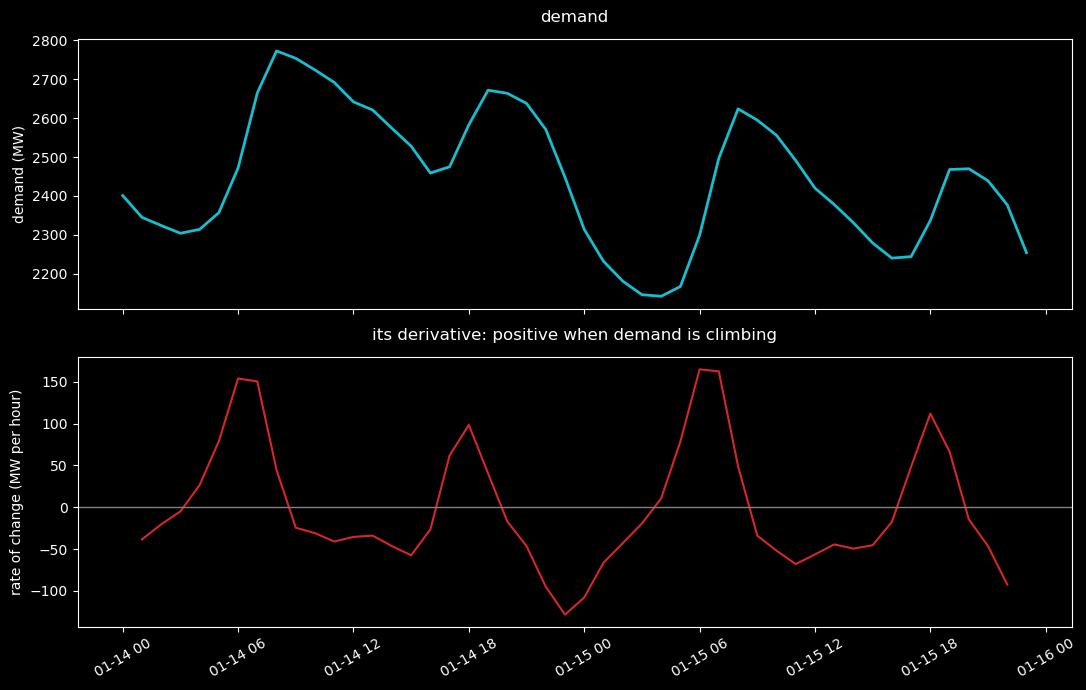

fastest increase :  +165.0 MW/hour at 2015-01-15 06:00:00
fastest decrease :  -128.5 MW/hour at 2015-01-14 23:00:00


In [4]:
day = mw['2015-01-14':'2015-01-15']
h_hours = 1.0
rate = (day.values[2:] - day.values[:-2]) / (2 * h_hours)
t_mid = day.index[1:-1]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(day.index, day.values, color="tab:cyan", lw=2)
axes[0].set_ylabel("demand (MW)")
axes[0].set_title("demand", pad=12)

axes[1].plot(t_mid, rate, color="tab:red", lw=1.5)
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_ylabel("rate of change (MW per hour)")
axes[1].set_title("its derivative: positive when demand is climbing", pad=12)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

peak_up = t_mid[np.argmax(rate)]
peak_down = t_mid[np.argmin(rate)]
print(f"fastest increase : {rate.max():+7.1f} MW/hour at {peak_up}")
print(f"fastest decrease : {rate.min():+7.1f} MW/hour at {peak_down}")

The steepest climb is in the morning as the region wakes up; the steepest fall is late at night. The
derivative crosses zero at the daily peak and trough, exactly the critical points of §3.5.

## 4. Smoothing before differentiating

Over a longer stretch the hourly noise wins, exactly as the previous notebook predicted. Differencing
a raw month of hourly data produces a solid band of spikes with no readable trend.

The fix is the same: average first. `resample('D').mean()` collapses each day to its mean, the time
series version of a rolling average, and *then* we differentiate. Note that $h$ is now **24 hours**,
so the arithmetic has to account for it.

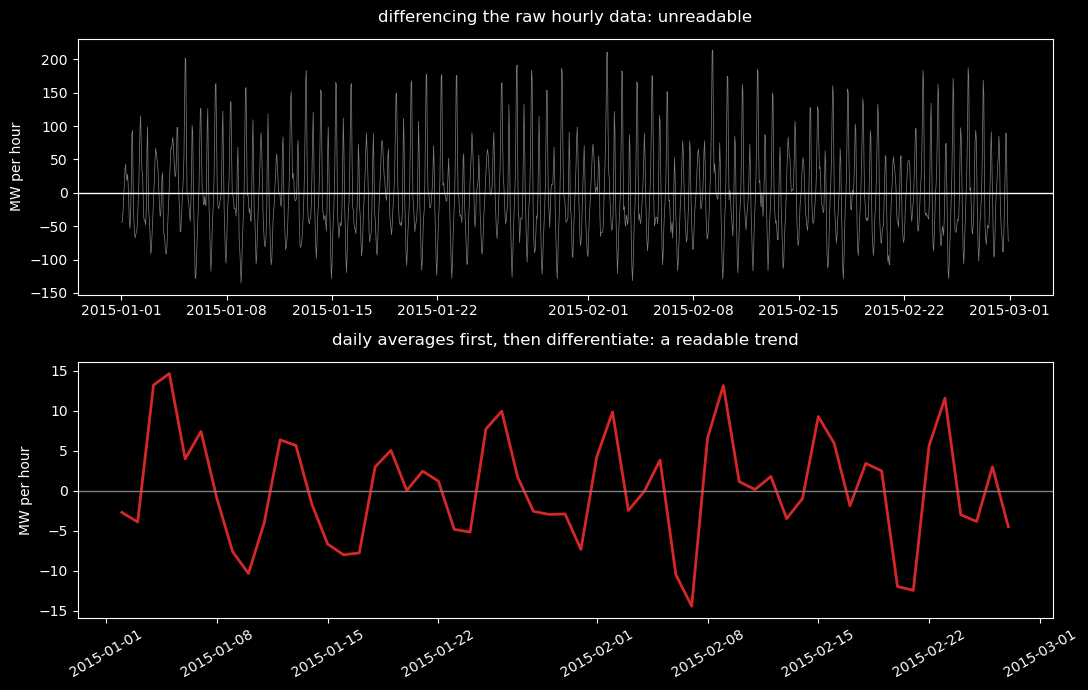

spread of the raw hourly rate   :     67.7 MW/hour
spread after daily averaging    :      6.7 MW/hour


In [5]:
month = mw['2015-01-01':'2015-02-28']

# naive: difference the raw hourly readings
raw_rate = (month.values[2:] - month.values[:-2]) / (2 * 1.0)

# smoothed: collapse to daily means first, then difference (h = 24 hours)
daily = month.resample('D').mean()
daily_rate = (daily.values[2:] - daily.values[:-2]) / (2 * 24.0)

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
axes[0].plot(month.index[1:-1], raw_rate, color="gray", lw=0.5)
axes[0].axhline(0, color="white", lw=1)
axes[0].set_ylabel("MW per hour")
axes[0].set_title("differencing the raw hourly data: unreadable", pad=12)

axes[1].plot(daily.index[1:-1], daily_rate, color="tab:red", lw=2)
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_ylabel("MW per hour")
axes[1].set_title("daily averages first, then differentiate: a readable trend", pad=12)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(f"spread of the raw hourly rate   : {raw_rate.std():8.1f} MW/hour")
print(f"spread after daily averaging    : {daily_rate.std():8.1f} MW/hour")

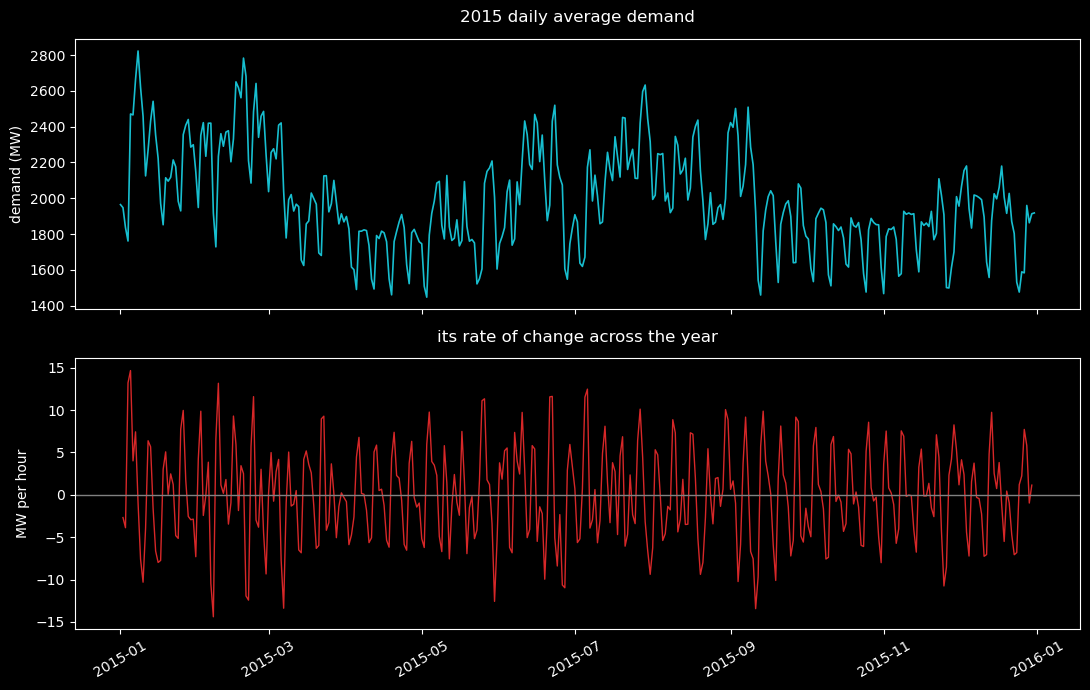

summer peak demand : 2,823 MW on 2015-01-08
lowest demand      : 1,448 MW on 2015-05-03


In [6]:
# the seasonal question: across a full year, when is demand changing fastest?
year_daily = mw['2015'].resample('D').mean()
year_rate = (year_daily.values[2:] - year_daily.values[:-2]) / (2 * 24.0)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(year_daily.index, year_daily.values, color="tab:cyan", lw=1.2)
axes[0].set_ylabel("demand (MW)")
axes[0].set_title("2015 daily average demand", pad=12)

axes[1].plot(year_daily.index[1:-1], year_rate, color="tab:red", lw=1)
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_ylabel("MW per hour")
axes[1].set_title("its rate of change across the year", pad=12)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(f"summer peak demand : {year_daily.max():,.0f} MW on {year_daily.idxmax().date()}")
print(f"lowest demand      : {year_daily.min():,.0f} MW on {year_daily.idxmin().date()}")

Demand peaks in summer (air conditioning) with a secondary winter rise (heating), and the rate of
change swings hardest during the spring and autumn transitions, which is exactly when a grid operator
has the most work to do.

None of this needed a formula. The whole analysis rests on subtracting neighbouring values and
dividing by the gap.

## 5. Summary

- Finite differences work on **real data with no formula**, they only need values.
- The choice of time scale *is* the choice of question: hourly differencing answers "what happens
  today," daily differencing answers "what happens this season."
- **Resampling to a coarser interval** is the time-series form of smoothing, and it is required
  before differencing a noisy series over any long stretch.
- Keep track of $h$ in real units. Daily averages mean $h = 24$ hours, and the derivative is MW per hour.
- The derivative crossing zero marks the peaks and troughs, the connection to optimization, next.

Next: using the derivative to *find* those peaks and troughs deliberately
(`U3-5_Optimize-1_DerivativeTest`).